In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv('data/ebike_distanta_franare.csv')
df

,speed,distance
0,15.4,3.6
1,16.2,3.8
2,17.2,4.3
3,19.4,5.1
4,25.7,7.6
5,26.8,8.5
6,32.6,9.9
7,34.7,11.9
8,36.3,14.2


In [63]:
df.describe()

,speed,distance
count,9.000000,9.000000
mean,24.922222,7.655556
std,8.253905,3.802996
min,15.400000,3.600000
25%,17.200000,4.300000
50%,25.700000,7.600000
75%,32.600000,9.900000
max,36.300000,14.200000


In [64]:
df = pd.read_csv('data/ebike_distanta_franare.csv')
df

,speed,distance
0,15.4,3.6
1,16.2,3.8
2,17.2,4.3
3,19.4,5.1
4,25.7,7.6
5,26.8,8.5
6,32.6,9.9
7,34.7,11.9
8,36.3,14.2


In [65]:
df.isna().sum()

speed       0
distance    0
dtype: int64

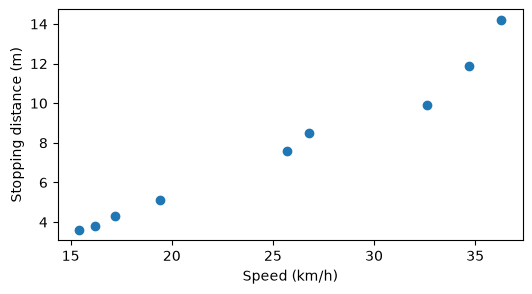

In [66]:
plt.figure(figsize=(6, 3))
plt.scatter(df['speed'], df['distance'])
plt.xlabel('Speed (km/h)')
plt.ylabel('Stopping distance (m)')
plt.show()

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
# Pregatirea vectorilor x si y
x = df[['speed']].values  # x trebuie sa fie un array 2D
y = df['distance'].values # y e un vector 1D

In [69]:
x
y

array([ 3.6,  3.8,  4.3,  5.1,  7.6,  8.5,  9.9, 11.9, 14.2])

In [70]:
model = LinearRegression()

In [71]:
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.45]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.64
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[23.35]


In [72]:
# citirea coeficientilor si a ecuatiei dreptei care rezulta din regresia liniara
coef = model.coef_[0]         # panta (coef a din ecuatia y=ax + b)
intercept = model.intercept_  # interceptul (coef b)

In [73]:
print('Linear model')
print(f'Coefficient (slope): {coef:.4f}')
print(f'Intercept: {intercept:.4f}')
print(f'Model equation: y = {coef:.4f}x + {intercept:.4f}')

Linear model
Coefficient (slope): 0.4532
Intercept: -3.6396
Model equation: y = 0.4532x + -3.6396


In [75]:
# predictia datelor
y_predict = model.predict(X)

mae = mean_absolute_error(y, y_predict)
mse = mean_squared_error(y, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_predict)

print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R^2: {r2:.4f}')

ValueError: Found input variables with inconsistent numbers of samples: [9, 18]

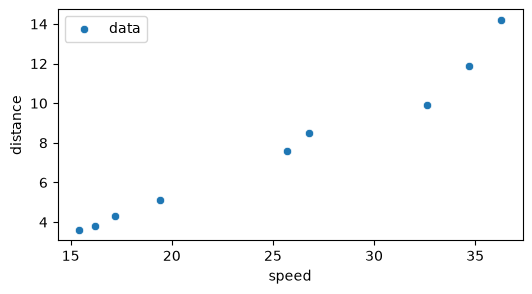

In [49]:
# Scatter plot si vizualizarea dreptei de regresie
plt.figure(figsize=(6,3))
sns.scatterplot(x=df['speed'], y=df['distance'], label='data')

x_min = 0
x_max = 40

y_min = round(coef * x_min + intercept, 4)
y_max = round(coef * x_max + intercept, 4)

plt.show()

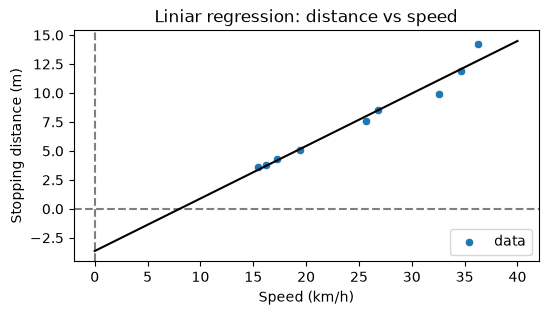

In [50]:
# Scatter plot si vizualizarea dreptei de regresie
plt.figure(figsize=(6,3))
sns.scatterplot(x=df['speed'], y=df['distance'], label='data')

x_min = 0
x_max = 40

y_min = round(coef * x_min + intercept, 4)
y_max = round(coef * x_max + intercept, 4)

plt.plot([x_min, x_max], [y_min, y_max], color='black')

plt.legend()
plt.xlabel('Speed (km/h)')
plt.ylabel('Stopping distance (m)')
plt.title('Liniar regression: distance vs speed')

plt.axhline(color='black', alpha=0.5, linestyle='--')
plt.axvline(color='black', alpha=0.5, linestyle='--')
plt.show()

In [51]:
# cautam tipare in distributia rezidurilor
residuals = y - y_predict

plt.figure(figsize=(6,3))
sns.scatterplot(x=y_predict, y=residuals)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted distance')
plt.ylabel('Residuals (actial - predicted)')
plt.title('Residuals vs predicted')
plt.show()

ValueError: operands could not be broadcast together with shapes (9,) (18,) 

In [52]:
df_low = pd.read_csv('data/ebike_date_viteze_mici.csv')
df_low # afiseaza DataFrame-ul

,speed,distance
0,0.0,0.00
1,2.0,0.04
2,3.0,0.10
3,5.0,0.20
4,7.0,0.33
5,8.0,0.86
6,10.0,1.50
7,11.0,1.79
8,13.0,2.26


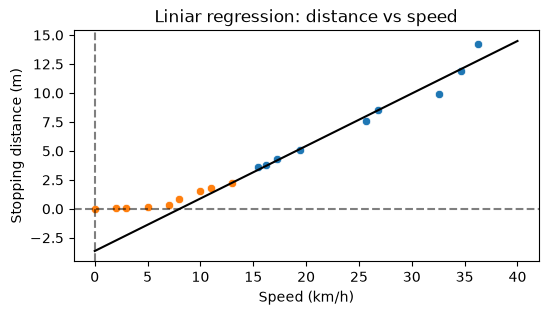

In [53]:
# Scatter plot si vizualizarea dreptei de regresie (include viteze mici)
plt.figure(figsize=(6,3))
sns.scatterplot(x=df['speed'], y=df['distance'], color='C0')
sns.scatterplot(x=df_low['speed'], y=df_low['distance'], color='C1')

x_min = 0
x_max = 40

y_min = round(coef * x_min + intercept, 4)
y_max = round(coef * x_max + intercept, 4)

plt.plot([x_min, x_max], [y_min, y_max], color='black')

plt.xlabel('Speed (km/h)')
plt.ylabel('Stopping distance (m)')
plt.title('Liniar regression: distance vs speed')

plt.axhline(color='black', alpha=0.5, linestyle='--')
plt.axvline(color='black', alpha=0.5, linestyle='--')
plt.show()

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [55]:
# Pregatirea vectorilor X si y
df_all = pd.concat([df, df_low])

X = df_all[['speed']].to_numpy()  
y = df_all['distance'].to_numpy()

In [56]:
X

array([[15.4],
       [16.2],
       [17.2],
       [19.4],
       [25.7],
       [26.8],
       [32.6],
       [34.7],
       [36.3],
       [ 0. ],
       [ 2. ],
       [ 3. ],
       [ 5. ],
       [ 7. ],
       [ 8. ],
       [10. ],
       [11. ],
       [13. ]])

In [57]:
# Avem nevoie de un pas intermediar pentru procesarea in continuare a lui X
poly = PolynomialFeatures(degree=2, include_bias=False)
X_quad = poly.fit_transform(X)

In [58]:
quad_model = LinearRegression()
quad_model.fit(X_quad, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.14,0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.4283
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[1791.19, 12.59]"


In [59]:
# Evaluarea modelului si predictii
y_pred = quad_model.predict(X_quad)

mse = mean_squared_error(y, y_pred)
rsquared = r2_score(y, y_pred)

print(f'Goodness of Fit (R²): {rsquared:.4f}')
print(f'MSE: {mse:.4f}')

Goodness of Fit (R²): 0.9886
MSE: 0.2116


In [60]:
# citirea coeficientilor si a ecuatiei modelului
c = quad_model.intercept_    # intercept
b, a = quad_model.coef_   # coef_speed, coef_speed^2